*Import packages*

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
np.bool=np.bool_

import pyemma
from pyemma.util.contexts import settings

from msmbuilder.io import load_trajs, load_generic

import os
import random
import deeptime

# 1. Featurization
***
*We must first define each frame of the simulation by geometric feature/s of the protein. Common featurization schemes:*
* **Torsions:** $\phi$ and $\psi$ backbone dihedral angles
* **Cartesian coordinates:** XYZ coordinates for $C_\alpha$ atoms
* **Distances:** Inter-residue $C_\alpha$ contact pairs.
***

#### Load Trajectories and Topology

We load the raw molecular dynamics simulation data from the local `./data` directory. 

* **Topology File:** `top.pdb`
* **Trajectory Files:** `0.xtc`, `1.xtc`, `2.xtc`, ...

In [2]:
pdb= './data/top.pdb'
files = []
indir="./data"
for filename in os.listdir(indir):
    if filename.endswith('.xtc'):
        files.append(os.path.join(indir,filename))
files = sorted(files, key=lambda x: int(os.path.splitext(os.path.basename(x))[0]))

print("Topology: " + pdb)
print("Trajectories: "+ str(files))

Topology: ./data/top.pdb
Trajectories: ['./data/0.xtc', './data/1.xtc', './data/2.xtc', './data/3.xtc']


**Featurize with torsions**

In [3]:
torsions_feat = pyemma.coordinates.featurizer(pdb)
torsions_feat.add_backbone_torsions(cossin=True, periodic=True)
torsions_data = pyemma.coordinates.load(files, features=torsions_feat)
print(len(torsions_data[0][0]))

Obtaining file info:   0%|                                | 0/4 [00:00<?, ?it/s]

getting output of FeatureReader:   0%|                    | 0/4 [00:00<?, ?it/s]

36


**Featurize with XYZ coordinates of $C_\alpha$ atoms**

In [4]:
CA_feat = pyemma.coordinates.featurizer(pdb)
ca_indices = CA_feat.select_Ca()
CA_feat.add_selection(indexes=ca_indices)
CA_data = pyemma.coordinates.load(files, features=CA_feat)
print(len(CA_data[0][0]))

Obtaining file info:   0%|                                | 0/4 [00:00<?, ?it/s]

getting output of FeatureReader:   0%|                    | 0/4 [00:00<?, ?it/s]

30


**Featurize with all atom distance pairs of $C_\alpha$ atoms** <div class="alert alert-block alert-warning">

<b>⚠️Does not scale well to larger proteins
<div>

In [8]:
dist_feat = pyemma.coordinates.featurizer(pdb)
dist_feat.add_distances_ca(periodic=False)
dist_data = pyemma.coordinates.load(files, features=dist_feat)
print(len(dist_data[0][0]))

Obtaining file info:   0%|                                | 0/4 [00:00<?, ?it/s]

getting output of FeatureReader:   0%|                    | 0/4 [00:00<?, ?it/s]

28


#### <b>Feature scoring with VAMP-2

In [55]:
def scorefeat(indata, lagtime):
    scores = []
    for i in range(len(indata)):
        training = indata[:i] + indata[i+1:]
        validation = indata[i]
        TICAtrain = deeptime.decomposition.TICA(lagtime = lagtime).fit(training).fetch_model()
        TICAval = deeptime.decomposition.TICA(lagtime = lagtime).fit(validation).fetch_model()
        score = TICAtrain.score(2, test_model=TICAval)
        scores.append(score)
    return(scores)
    #print(score)

*Adjust lagtime to use with TICA scoring function*

In [56]:
lagtime = 100
scoretorsions = scorefeat(torsions_data, lagtime)
scoreCA = scorefeat(CA_data, lagtime)
scoredist = scorefeat(dist_data, lagtime)

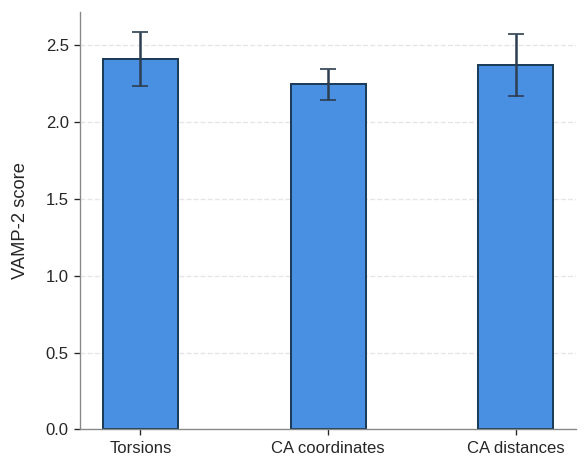

In [119]:
concscores = [scoretorsions, scoreCA, scoredist]
scorename = ["Torsions", "CA coordinates", "CA distances"]

graphscore = []
grapherr = []
for scores in concscores:
    n = len(scores)
    avg = sum(scores) / n
    variance = sum((x - avg) ** 2 for x in scores) / (n - 1)
    stdev = variance ** 0.5
    graphscore.append(avg)
    grapherr.append(stdev)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4), dpi=120)

ax.bar(
    scorename, 
    graphscore, 
    yerr=grapherr, 
    width=0.4, 
    capsize=5, 
    color='#4A90E2', 
    edgecolor='#1C3D5A', 
    linewidth=1.2,
    error_kw={'ecolor': '#2C3E50', 'lw': 1.5} 
)

#ax.set_title('VAMP-2 score', fontsize=12, fontweight='bold', pad=15)
ax.set_ylabel('VAMP-2 score', fontsize=11, labelpad=10)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#CCCCCC')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

plt.tight_layout()
plt.savefig('0_featurescoring.png', bbox_inches='tight')

***
#### Save featurized trajectories into './feat' folder, based on the feature set with the highest score*

In [12]:
os.makedirs('feat', exist_ok=True)
for i, traj in enumerate(torsions_data):
    file_path = os.path.join('feat', f'{i}.npy')
    np.save(file_path, traj)

In [ ]:
os.makedirs('feat', exist_ok=True)
for i, traj in enumerate(CA_data):
    file_path = os.path.join('feat', f'{i}.npy')
    np.save(file_path, traj)

In [30]:
os.makedirs('feat', exist_ok=True)
for i, traj in enumerate(dist_data):
    file_path = os.path.join('feat', f'{i}.npy')
    np.save(file_path, traj)

***
## 1.2 SpectraloASIS (Optional)

For molecular dynamics simulations that generate a large number of features (e.g. all-atom pairwise contact maps), an initial pre-reduction step may be required.

Features are compressed and saved as `.npy` arrays directly to the `./feat_reduced/` directory.

> **Source:** This module is originally from the [qMSM Tutorial repository](https://github.com/ykhdrew/qMSM_tutorial). 
***

In [120]:
import os
import numpy as np
import pandas as pd
from pyemma.coordinates.transform._tica_base import *
from pyemma.coordinates.transform.nystroem_tica import *
from pyemma.coordinates import tica
import matplotlib.pyplot  as plt
import pickle
from multiprocessing import Pool
import itertools
np.bool=np.bool_

os.makedirs('./SpectralOasis/',exist_ok=True)
spectraldir="./SpectralOasis/"

def load_feat_data(data_dir):
    files = sorted([f for f in os.listdir(data_dir) if f.endswith('.npy')])
    data = [np.load(os.path.join(data_dir, f), allow_pickle=True) for f in files]
    return data
input_feature_data = load_feat_data('feat')

### SpectraloASIS Hyperparameters:
| Parameter | Type / Units | Description |
| :--- | :--- | :--- |
| `lt` | ps | Lag times evaluated during TICA |
| `dt` | ps | Time step per single frame of the trajectory. |
| `columns` | List of `int` | Number of reduced feature numbers to test and evaluate timescales for. |
| `no_initial_column` | `int` | Size of the randomized starting feature subset |
| `no_batch` | `int` | Number of features added in each iteration |

In [134]:
lt=[10000] #in ps
dt=100 #in ps
columns=[4,8,12,16,20,24,28,32,36]

no_initial_column = 4
no_batch = 4

lts_in_steps=[ int(round(i/dt)) for i in lt]
num_features = input_feature_data[0].shape[1]

initial_columns= np.random.choice(num_features,no_initial_column,replace=False)
#parameters=[(a,b) for a in columns for b in lts_in_steps]
parameters = [
    (a, b, initial_columns, no_batch) 
    for a in columns 
    for b in lts_in_steps
]
print("no. of features tested: ", columns)

no. of features tested:  [4, 8, 12, 16, 20, 24, 28, 32, 36]


#### Execute SpectraloASIS
**Output Destination:** Selected indices are written as index maps into:
  `./SpectralOasis/lagtime_<lt>ps/`

In [135]:
def run_SpectraloASIS(max_columns, lt, initial_columns, no_batch, 
                      dt=dt, num_features=num_features, 
                      input_feature_data=input_feature_data, 
                      spectraldir="./SpectralOasis/"):
    """
    Running Spectral oASIS 

    Parameters
    ----------
    max_columns : int
        The number of features to be selected

    input_feature_data: list containing ndarrays(dtype=int) or ndarray(n, dtype=int))
        features to be selected

    num_features: int
        The number of features in the full set

    spectraldir: str, default="./SpectralOasis/"
        The directory to save output

    Return
    ----------
    t.timescales:
         timescales for tlCA perform with this number of features

    """
    t = NystroemTICA(lt, max_columns, initial_columns=initial_columns, nsel=no_batch)
    t.estimate(input_feature_data)   ##running oasis_tica
    os.makedirs('{}{}'.format(spectraldir,int(lt)),exist_ok=True)
    np.savetxt("{}{}/feature_column{}_ticalag_{}.txt".format(spectraldir,int(lt),max_columns,int(lt)), t.column_indices, fmt='%d')
    np.savetxt("{}{}/timescales_column{}_ticalag_{}.txt".format(spectraldir,int(lt),max_columns,int(lt)), t.timescales)
    return lt,max_columns,t.timescales

with Pool() as pool: 
    results = pool.starmap(run_SpectraloASIS,parameters)

df = pd.DataFrame(results)
df.to_pickle("{}timescales.pickl".format(spectraldir))  

*Graph the implied timescale over number of features added*

/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/decorator.py:232: PyEMMA_DeprecationWarning: Call to deprecated function "tica". Called from /home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/decorator.py line 232. Use deeptime.decomposition.TICA instead.
  return caller(func, *(extras + args), **kw)


calculate covariances:   0%|                              | 0/4 [00:00<?, ?it/s]

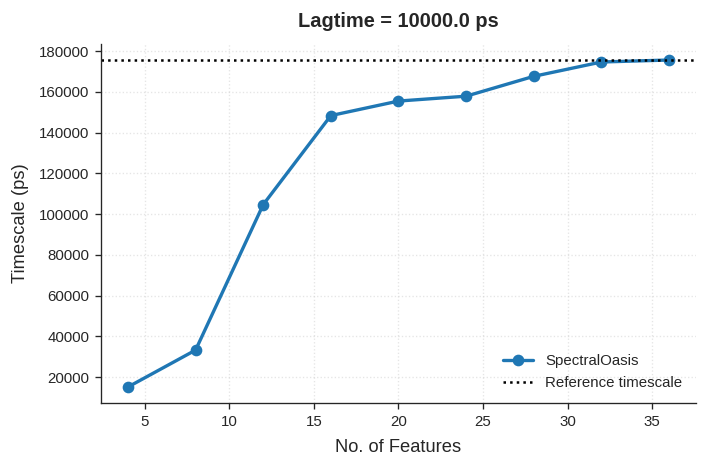

In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

columns_ = [i for i in columns] 

data = pd.read_pickle("{}timescales.pickl".format(spectraldir))

for n in lts_in_steps:
    t_timescales = data.loc[data[0] == n][2].values
    
    timescales = []
    for i in range(len(columns_)):
        timescales.append(t_timescales[i][0])
    
    timescales = np.array(timescales) * dt
    
    TICA = tica(input_feature_data, lag=n)
    full_feature_baseline = TICA.timescales[0] * dt 
    
    fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
    
    ax.plot(columns_, timescales, "-o", color="#1f77b4", lw=2, label="SpectralOasis")
    
    ax.axhline(
        y=full_feature_baseline, 
        color="k", 
        lw=1.5, 
        linestyle=":", 
        label="Reference timescale"
    )
    
    ax.set_ylabel("Timescale (ps)", fontsize=11, labelpad=6)
    ax.set_xlabel("No. of Features", fontsize=11, labelpad=6)
    ax.set_title("Lagtime = {0:.1f} ps".format(n * dt), fontsize=12, fontweight='bold', pad=10)
    
    ax.tick_params(axis='both', labelsize=9)
    ax.set_axisbelow(True)
    ax.grid(axis='both', linestyle=':', alpha=0.5)
    
    # Spines clean-up
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
        
    ax.legend(frameon=False, loc="best", fontsize=9)
    
    plt.tight_layout()
    plt.savefig(spectraldir + "Timescale_vs_FeatureNo_ticalag_{0:.1f}.png".format(n * dt), dpi=300)
    plt.show()

***
#### Random selection (for demonstration purposes only)

In [155]:
import random

lag = 100

# Generate a shuffled list of feature indices
s = list(range(len(input_feature_data[0][0])))  # Corrected index generation
random.shuffle(s)  # Shuffle in place

num = 4  # Number of features per group
indices = []
rand_timescales = []
rand_feat = []
for i in range(len(s) // num):  
    selected_indices = s[-num:]  # Get last 'num' elements
    indices.extend(selected_indices)  # Use extend() to flatten the list
    del s[-num:]  # Remove selected indices from the list
    
    red_features = []
    for n in range(len(input_feature_data)):
        red_features.append(input_feature_data[n][:, indices])
    red_TICA = tica(red_features, lag=lag)
    rand_timescales.append(red_TICA.timescales[0]*100)
    rand_feat.append((i+1)*num)
#print(rand_timescales)

/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/decorator.py:232: PyEMMA_DeprecationWarning: Call to deprecated function "tica". Called from /home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/decorator.py line 232. Use deeptime.decomposition.TICA instead.
  return caller(func, *(extras + args), **kw)


calculate covariances:   0%|                              | 0/4 [00:00<?, ?it/s]

/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/decorator.py:232: PyEMMA_DeprecationWarning: Call to deprecated function "tica". Called from /home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/decorator.py line 232. Use deeptime.decomposition.TICA instead.
  return caller(func, *(extras + args), **kw)


calculate covariances:   0%|                              | 0/4 [00:00<?, ?it/s]

/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/decorator.py:232: PyEMMA_DeprecationWarning: Call to deprecated function "tica". Called from /home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/decorator.py line 232. Use deeptime.decomposition.TICA instead.
  return caller(func, *(extras + args), **kw)


...

calculate covariances:   0%|                              | 0/4 [00:00<?, ?it/s]

/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/decorator.py:232: PyEMMA_DeprecationWarning: Call to deprecated function "tica". Called from /home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/decorator.py line 232. Use deeptime.decomposition.TICA instead.
  return caller(func, *(extras + args), **kw)


calculate covariances:   0%|                              | 0/4 [00:00<?, ?it/s]

/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/decorator.py:232: PyEMMA_DeprecationWarning: Call to deprecated function "tica". Called from /home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/decorator.py line 232. Use deeptime.decomposition.TICA instead.
  return caller(func, *(extras + args), **kw)


calculate covariances:   0%|                              | 0/4 [00:00<?, ?it/s]

/home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/decorator.py:232: PyEMMA_DeprecationWarning: Call to deprecated function "tica". Called from /home/samueltien/.conda/envs/pyemma/lib/python3.11/site-packages/decorator.py line 232. Use deeptime.decomposition.TICA instead.
  return caller(func, *(extras + args), **kw)


calculate covariances:   0%|                              | 0/4 [00:00<?, ?it/s]

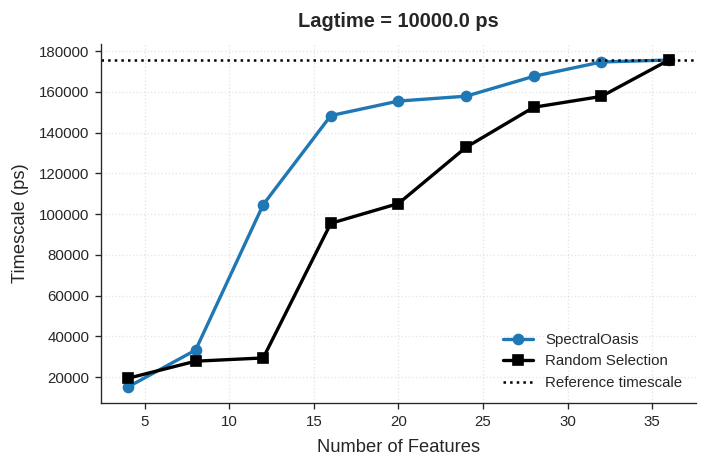

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

columns_ = [i for i in columns] 

data = pd.read_pickle("{}timescales.pickl".format(spectraldir))

rand_x = [num * (i + 1) for i in range(len(rand_timescales))]
# Convert random timescales to physical units (ps) assuming it is in steps
rand_timescales_ps = np.array(rand_timescales)# * dt

for n in lts_in_steps:
    t_timescales = data.loc[data[0] == n][2].values
    
    timescales = []
    for i in range(len(columns_)):
        timescales.append(t_timescales[i][0])
    
    timescales = np.array(timescales) * dt
    
    TICA = tica(input_feature_data, lag=n)
    full_feature_baseline = TICA.timescales[0] * dt 
    
    fig, ax = plt.subplots(figsize=(6, 4), dpi=120)
    
    ax.plot(columns_, timescales, "-o", color="#1f77b4", lw=2, label="SpectralOasis")
    ax.plot(rand_x, rand_timescales_ps, "-s", color="#000000", lw=2, label="Random Selection")
    
    ax.axhline(
        y=full_feature_baseline, 
        color="k", 
        lw=1.5, 
        linestyle=":", 
        label="Reference timescale"
    )
    
    ax.set_ylabel("Timescale (ps)", fontsize=11, labelpad=6)
    ax.set_xlabel("Number of Features", fontsize=11, labelpad=6)
    ax.set_title("Lagtime = {0:.1f} ps".format(n * dt), fontsize=12, fontweight='bold', pad=10)
    
    ax.tick_params(axis='both', labelsize=9)
    ax.set_axisbelow(True)
    ax.grid(axis='both', linestyle=':', alpha=0.5)
    
    # Spines clean-up
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
        
    ax.legend(frameon=False, loc="best", fontsize=9)
    
    plt.tight_layout()
    plt.savefig(spectraldir + "Timescale_vs_FeatureNo_ticalag_{0:.1f}.png".format(n * dt), dpi=300)
    plt.show()

### Export optimal feature set

Update the `features_kept` to point to your chosen `.txt` or index map file (e.g., the text file containing the converged feature indices of interest).

* Processed matrices are written into the `./feat_reduced/` directory.

In [160]:
features_kept = 'SpectralOasis/100/feature_column32_ticalag_100.txt'
input_dir = 'feat'
output_dir = 'feat_reduced'

with open(features_kept, 'r') as f:
    indices = [int(line.strip()) for line in f.readlines()]

os.makedirs(output_dir, exist_ok=True)

for filename in os.listdir(input_dir):
    if filename.endswith('.npy'):
        filepath = os.path.join(input_dir, filename)
        features = np.load(filepath)
        
        reduced_features = features[:, indices]
        
        output_filepath = os.path.join(output_dir, filename)
        np.save(output_filepath, reduced_features)

print(f"Reduced features saved to '{output_dir}'")

Reduced features saved to 'feat_reduced'


# 2. Time-Lagged Independent Component Analysis (TICA)
***
We perform a linear coordinate transformation to project our high-dimensional structural data onto a lower dimensional kinetic space.

### TICA hyperparameter selection
* To optimize the number of dimensions

In [15]:
def load_reduced_data(data_dir, stride):
    reduced_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.npy')])
    reduced_data = [np.load(os.path.join(data_dir, f)) for f in reduced_files]
    reduced_data = [data[::stride] for data in reduced_data]
    return reduced_data

def TICAdimscore(training, validation, dim, lagtime):
    koopmantrain = deeptime.decomposition.TICA(lagtime = lagtime, dim=dim).fit_fetch(training)
    koopmanval = deeptime.decomposition.TICA(lagtime = lagtime, dim=dim).fit_fetch(validation)
    score = koopmantrain.score(2,koopmanval)
    return score

Adjust `lagtime` for TICA, `dims` for the list of dimensions to test

In [58]:
ftrajs = load_reduced_data("feat", 1)

lagtime = 100
dims = [n+1 for n in range(20)]

scores = []
err = []
for dim in dims:
    tempscore = []
    for i in range(len(ftrajs)):
        training = ftrajs[:i] + ftrajs[i+1:]
        validation = ftrajs[i]
        tempscore.append(TICAdimscore(training, validation, dim, lagtime))

    n = len(tempscore)
    avg = sum(tempscore) / n
    variance = sum((x - avg) ** 2 for x in tempscore) / (n - 1)
    stdev = variance ** 0.5
    scores.append(avg)
    err.append(stdev)

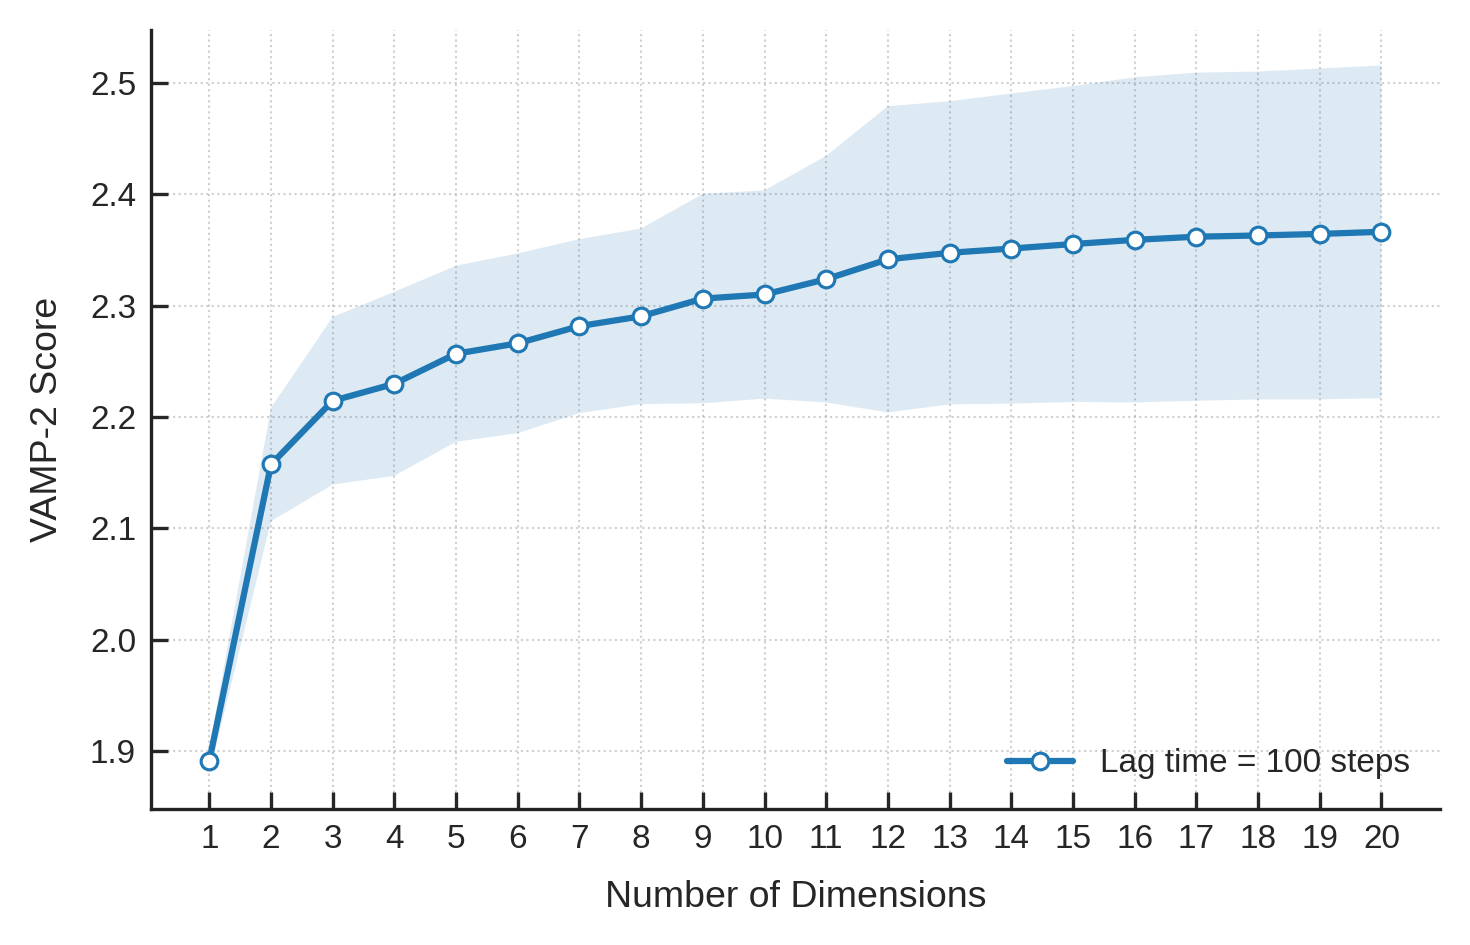

In [59]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'Liberation Sans']
plt.rcParams['text.usetex'] = False 

dims_arr = np.array(dims)
scores_arr = np.array(scores)
err_arr = np.array(err)

fig, ax = plt.subplots(figsize=(5, 3.25), dpi=300)

main_color = '#1f77b4'
ax.fill_between(
    dims_arr, 
    scores_arr - err_arr, 
    scores_arr + err_arr, 
    color=main_color, 
    alpha=0.15, 
    edgecolor='none'
)

# 2. Primary Data Line
ax.plot(
    dims_arr, 
    scores_arr, 
    color=main_color, 
    linewidth=1.5,  
    marker='o', 
    markersize=4, 
    markeredgewidth=0.75,
    markerfacecolor='white', 
    markeredgecolor=main_color,
    label=f'Lag time = {str(lagtime)} steps'
)

ax.set_xlabel('Number of Dimensions', fontsize=9, fontweight='normal', labelpad=6)
ax.set_ylabel('VAMP-2 Score', fontsize=9, fontweight='normal', labelpad=6)

ax.set_xticks(dims)
ax.tick_params(axis='both', which='major', labelsize=8, direction='in', top=False, right=False, width=0.8, length=4)

ax.set_axisbelow(True)
ax.grid(axis='both', linestyle=':', alpha=0.5, color='#A0A0A0', linewidth=0.5)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(0.8)
    ax.spines[spine].set_color('#222222')

ax.legend(frameon=False, loc='lower right', fontsize=8)

plt.tight_layout()
# Save as both high-res PNG and vector PDF (PDF is standard for journal submissions)
plt.savefig('2_TICAdim.png', bbox_inches='tight', dpi=600)
plt.savefig('2_TICAdim.pdf', bbox_inches='tight')
plt.show()

### Run TICA
- Pass data to MSMbuilder (to sample structures later)
- Adjust `step_ps` to the length of each timestep in the simulation

In [26]:
from msmbuilder.io import gather_metadata, save_meta, NumberedRunsParser

## Change step_ps to amount of time per step
parser = NumberedRunsParser(
    traj_fmt="{run}.xtc",
    top_fn="data/top.pdb",
    step_ps=100,
)
meta = gather_metadata("data/*.xtc", parser)
save_meta(meta)

Adjust `n_components` to the number of dimensions, and `lag_time` to the lag time of choice <br>
This will generate the TICA trajectories for every trajectory in the shape: 
*Number of frames * Dimensions* <br> The output is saved to `./ttrajs`

In [27]:
from msmbuilder.io import load_trajs, save_trajs, save_generic
from msmbuilder.decomposition import tICA

data_dir = 'feat'
## Load
tica = tICA(n_components=12, lag_time=100, kinetic_mapping=True)
meta, ftrajs = load_trajs(data_dir)

## Fit
tica.fit(ftrajs.values())

## Transform
ttrajs = {}
for k, v in ftrajs.items():
    ttrajs[k] = tica.partial_transform(v)

## Save
save_trajs(ttrajs, 'ttrajs', meta)
save_generic(tica, 'tica.pickl')

*Plot histogram*

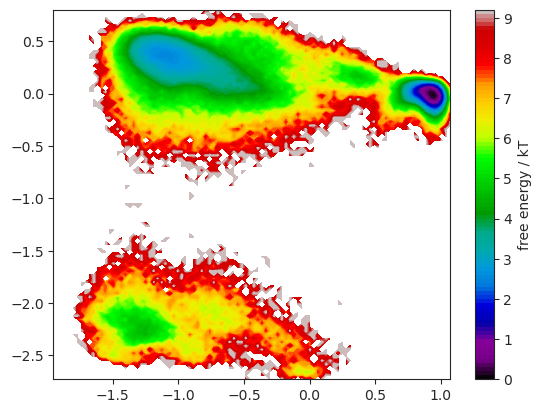

In [28]:
import matplotlib
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pyemma.plots as mplt

from msmbuilder.io import load_trajs, load_generic

sns.set_style('ticks')
colors = sns.color_palette()

## Load
tica = load_generic('tica.pickl')
meta, ttrajs = load_trajs('ttrajs')
txx = np.concatenate(list(ttrajs.values()))

## Plot 1
mplt.plot_free_energy(np.vstack(txx)[:,0], np.vstack(txx)[:,1])
plt.savefig('2_tica-heatmap.png')

# 3. Clustering
***
We can now cluster on the reduced feature space to obtain the discrete trajectory

### Optimising cluster count

In [113]:
def load_reduced_data(data_dir, stride):
    reduced_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.npy')])
    reduced_data = [np.load(os.path.join(data_dir, f)) for f in reduced_files]
    reduced_data = [data[::stride] for data in reduced_data]
    return reduced_data

def scorecluster(training, validation, lagtime):
    Ctrain = deeptime.markov.TransitionCountEstimator(lagtime=lagtime, count_mode="sliding").fit_fetch(training)
    MLEtrain = deeptime.markov.msm.MaximumLikelihoodMSM().fit_fetch(Ctrain)
    score = MLEtrain.score(validation,2)
    return(score)

Adjust `lagtime` to be used with the MLE, `clusters` to the cluster number tested, `repeats` to the number of repeats per cluster number (to account for the stochiastic algorithm)

In [114]:
lagtime = 500
clusters = [5,20,40,50,60]
repeats = 2

ttrajs = load_reduced_data("ttrajs",1)

scores = []
err = []
for cluster in clusters:
    tempscores = []
    for k in range(repeats):
        estimator = deeptime.clustering.KMeans(n_clusters=cluster)
        model = estimator.fit(ttrajs).fetch_model()
        dtrajs = [model.transform(traj) for traj in ttrajs]
        for i in range(len(dtrajs)):
            training = dtrajs[:i] + dtrajs[i+1:]
            validation = dtrajs[i]
            tempscores.append(scorecluster(training, validation, lagtime))
    n = len(tempscores)
    avg = sum(tempscores) / n
    variance = sum((x - avg) ** 2 for x in tempscores) / (n - 1)
    stdev = variance ** 0.5
    scores.append(avg)
    err.append(stdev)

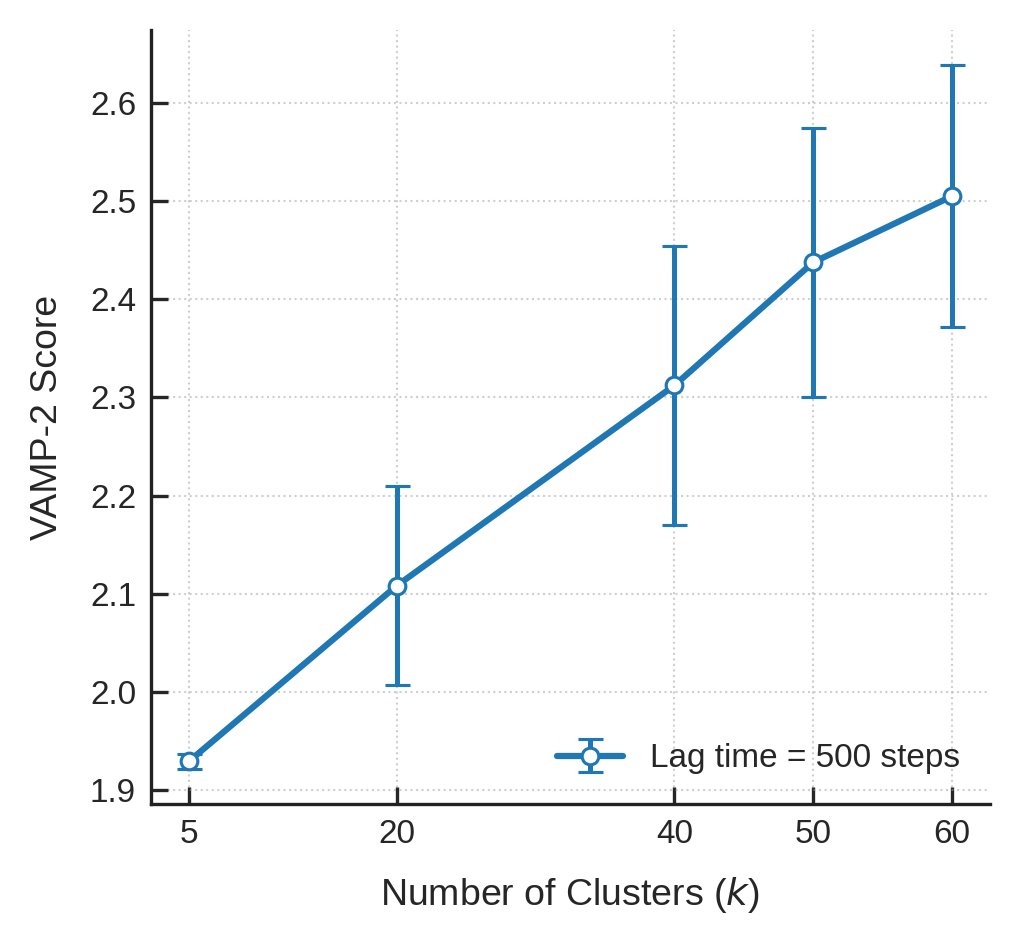

In [115]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'Liberation Sans']
plt.rcParams['text.usetex'] = False  

clusters_arr = np.array(clusters)
scores_arr = np.array(scores)
err_arr = np.array(err)

fig, ax = plt.subplots(figsize=(3.5, 3.25), dpi=300)

main_color = '#1f77b4'

ax.errorbar(
    clusters_arr, 
    scores_arr, 
    yerr=err_arr,
    color=main_color, 
    linewidth=1.5,
    marker='o', 
    markersize=4, 
    markeredgewidth=0.75,
    markerfacecolor='white',
    markeredgecolor=main_color,
    capsize=3,
    capthick=1.0,
    elinewidth=1.2,
    label=f'Lag time = {lagtime} steps'
)

ax.set_xlabel('Number of Clusters ($k$)', fontsize=9, fontweight='normal', labelpad=6)
ax.set_ylabel('VAMP-2 Score', fontsize=9, fontweight='normal', labelpad=6)

ax.set_xticks(clusters)
ax.tick_params(axis='both', which='major', labelsize=8, direction='in', top=False, right=False, width=0.8, length=4)

ax.set_axisbelow(True)
ax.grid(axis='both', linestyle=':', alpha=0.5, color='#A0A0A0', linewidth=0.5)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(0.8)
    ax.spines[spine].set_color('#222222')

ax.legend(frameon=False, loc='lower right', fontsize=8)

plt.tight_layout()

# Save outputs
plt.savefig('3_clusterVAMP2.png', bbox_inches='tight', dpi=600)
plt.savefig('3_clusterVAMP2.pdf', bbox_inches='tight')
plt.show()

### Execute clustering
Adjust `n_clusters` for the number of clusters to use

In [73]:
from msmbuilder.io import load_trajs, save_trajs, save_generic
from msmbuilder.cluster import MiniBatchKMeans

meta, ttrajs = load_trajs('ttrajs')

kclusters = MiniBatchKMeans(n_clusters=50)
kclusters.fit([traj for traj in ttrajs.values()])

ktrajs = {}
for k, v in ttrajs.items():
    ktrajs[k] = kclusters.partial_transform(v)

#print(kmeans.summarize())
save_trajs(ktrajs, 'ktrajs', meta)
save_generic(kclusters, 'kclusters.pickl')

*Plot clusters on the TICA space*

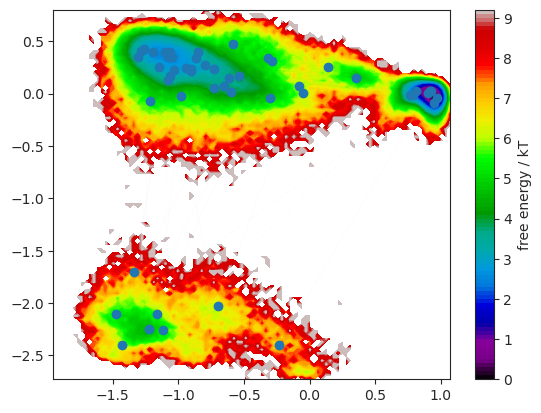

In [74]:
import matplotlib
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pyemma.plots as mplt

from msmbuilder.io import load_trajs, load_generic

sns.set_style('ticks')
colors = sns.color_palette()

## Load
kclusters = load_generic('kclusters.pickl')
meta, ktrajs = load_trajs('ktrajs')
meta, ttrajs = load_trajs('ttrajs', meta)
txx = np.concatenate(list(ttrajs.values()))


mplt.plot_free_energy(np.vstack(txx)[:,0], np.vstack(txx)[:,1])
plt.plot(kclusters.cluster_centers_[:, 0], kclusters.cluster_centers_[:, 1], linewidth=0.01, marker='o')
plt.savefig('3_ticawithclusters.png')
plt.show()

### 3.3 Sample the clusters and get structures (OPTIONAL)
Generates cluster numbers on the heatmap which correspond to the clusters

/tmp/ipykernel_6986/2589386977.py:66: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(coo[:, 0], coo[:, 1], c=colors[i % 6], s=40)


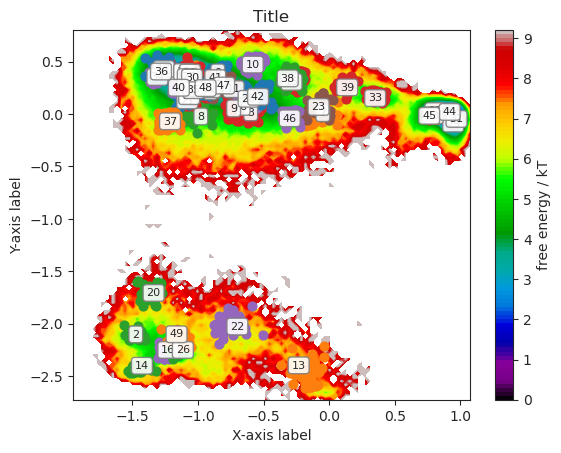

In [77]:
import mdtraj as md
import os

from msmbuilder.io.sampling import sample_states
from msmbuilder.io import load_trajs, save_generic, preload_top, backup, load_generic

import matplotlib
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pyemma.plots as mplt

#matplotlib.use("Agg")

## Load
meta, ttrajs = load_trajs('ttrajs')
kclusters = load_generic("kclusters.pickl")

## Sample
inds = sample_states(ttrajs,
                     kclusters.cluster_centers_,
                     k=30)

save_generic(inds, "cluster-sample-inds.pickl")

## Make trajectories
top = preload_top(meta)
out_folder = "2_cluster_samples"
backup(out_folder)
os.mkdir(out_folder)

index_file = os.path.join(out_folder, "index.txt")

with open(index_file, 'w') as f:
    f.write("State\tTrajectory\tFrame\n")  # Header

    for state_i, state_inds in enumerate(inds):
        traj = md.join(
            md.load_frame(meta.loc[traj_i]['traj_fn'], index=frame_i, top=top)
            for traj_i, frame_i in state_inds
        )
        traj.save("{}/{}.xtc".format(out_folder, state_i))

        # Write the indices to the file
        for traj_i, frame_i in state_inds:
            f.write(f"{state_i}\t{traj_i}\t{frame_i}\n")

colors = sns.color_palette()

## Load
meta, ttrajs = load_trajs('ttrajs')
txx = np.concatenate(list(ttrajs.values()))
kclusters = load_generic('kclusters.pickl')

inds = load_generic("cluster-sample-inds.pickl")
coordinates = [
    np.asarray([ttrajs[traj_i][frame_i, :] for traj_i, frame_i in state_inds])
    for state_inds in inds
    ]


mplt.plot_free_energy(np.vstack(txx)[:,0], np.vstack(txx)[:,1])

# Overlay scatter plot of cluster centers and their indices
for i, coo in enumerate(coordinates):
    plt.scatter(coo[:, 0], coo[:, 1], c=colors[i % 6], s=40)
    plt.text(kclusters.cluster_centers_[i, 0],
             kclusters.cluster_centers_[i, 1],
             "{}".format(i),
             ha='center',
             va='center',
             size=8,
             bbox=dict(
                 boxstyle='round',
                 fc='w',
                 ec="0.5",
                 alpha=0.9,
             ),
             zorder=10,
             )
plt.xlabel('X-axis label')
plt.ylabel('Y-axis label')
plt.title('Title')
plt.savefig('3_trajectorieswithclusters.png')

# 4. MSM validation
***

### Implied timescales over lag time
- With increasing lag time, the timescales should converge. Timescales falling under Y=X cannot be used

*Quick timescale test using MLE* <br>
Adjust `lagtimes` to lagtimes used with the estimator

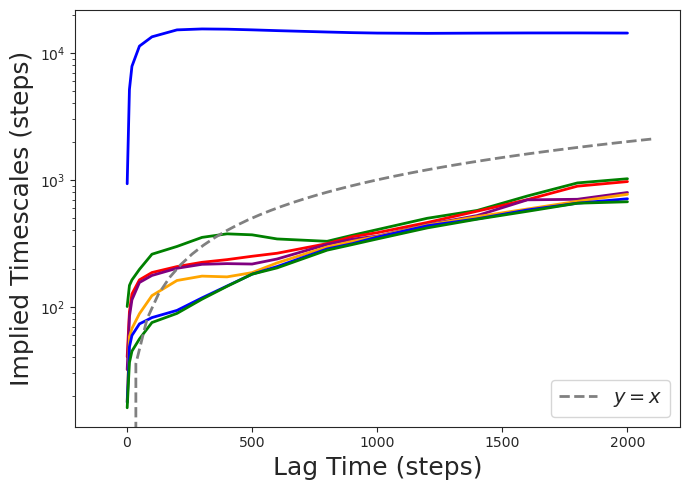

In [76]:
import numpy as np
import os
import matplotlib.pyplot as plt
from multiprocessing import Pool
import pandas as pd
from msmbuilder.io import load_trajs
import deeptime

def load_reduced_data(data_dir, stride):
    reduced_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.npy')])
    reduced_data = [np.load(os.path.join(data_dir, f)) for f in reduced_files]
    reduced_data = [data[::stride] for data in reduced_data]
    return reduced_data

discrete_trajs = load_reduced_data("ktrajs", 1)

lagtimes = [1, 10, 20, 50, 100, 200, 300, 400, 500, 600,800,900, 1000, 1200, 1400, 1600, 1800, 2000]#,2200,2400,2500,2700,3000,3500,4000]

models = []
for lag in lagtimes:
    counts = deeptime.markov.TransitionCountEstimator(lagtime=lag, count_mode="sliding").fit_fetch(discrete_trajs)
    msm = deeptime.markov.msm.MaximumLikelihoodMSM().fit_from_counts(counts).fetch_model()
    models.append(msm)

timescales_data = []
for model in models:
    timescales = model.timescales()[:7]  # Get the first 7 timescales
    timescales_data.append(timescales)

timescales_df = pd.DataFrame(timescales_data, columns=[f'timescale_{i}' for i in range(len(timescales_data[0]))])
timescales_df['lag_time'] = lagtimes

def plot_timescales(ax):
    line_colours = ['blue', 'green', 'red', 'purple', 'orange']
    
    for i in range(len(timescales_df.columns) - 1):  # Exclude lag_time column
        ax.plot(timescales_df['lag_time'],
                timescales_df[f'timescale_{i}'],
                linewidth=2, color=line_colours[i % len(line_colours)],
                label=None  # pandas interference
                )
    
    xmin, xmax = ax.get_xlim()
    xx = np.linspace(xmin, xmax)
    ax.plot(xx, xx, linestyle='--', color='gray', label='$y=x$', linewidth=2)
    ax.legend(loc='best', fontsize=14)
    ax.set_xlabel('Lag Time (steps)', fontsize=18)
    ax.set_ylabel('Implied Timescales (steps)', fontsize=18)
    ax.set_yscale('log')

# Create figure and axis for plotting
fig, ax = plt.subplots(figsize=(7, 5))
plot_timescales(ax)
fig.tight_layout()
fig.savefig('4_MLE-timescales.png')
plt.show()


*Bayesian MLE fitting for error bars*

In [92]:
import numpy as np
import os
import matplotlib.pyplot as plt
from multiprocessing import Pool
import pandas as pd
from msmbuilder.io import load_trajs
import deeptime

def load_reduced_data(data_dir, stride):
    reduced_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.npy')])
    reduced_data = [np.load(os.path.join(data_dir, f)) for f in reduced_files]
    reduced_data = [data[::stride] for data in reduced_data]
    return reduced_data

discrete_trajs = load_reduced_data("ktrajs", 1)

lagtimes = [1, 10, 20, 50, 100, 200, 300, 400, 500, 600, 1000, 1200, 1400, 1600,2000]#,2500,3000]

baymodels = []


for lag in lagtimes:
    bcounts = deeptime.markov.TransitionCountEstimator(lagtime=lag, count_mode="effective").fit_fetch(discrete_trajs)
    bmsm = deeptime.markov.msm.BayesianMSM().fit(bcounts).fetch_model()
    baymodels.append(bmsm)
    print(lag)

1
10
20
50
100
200
300
400
500
600
1000
1200
1400
1600
2000


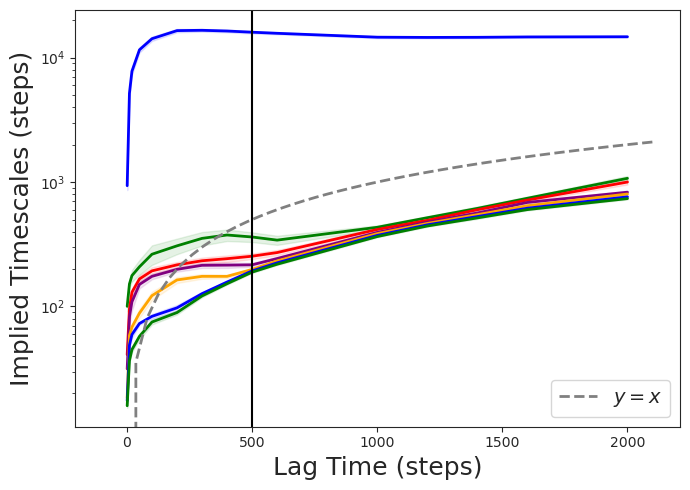

In [95]:
import math

timescales_data = []

errors_data = []
for model in baymodels:
    timescales = model.gather_stats("timescales").mean[:7]  # Get the first 7 timescales
    timescales_data.append(timescales)
    errors = model.gather_stats("timescales").std[:7]  # Get the first 7 timescales
    errors_data.append(errors)

    



timescales_df = pd.DataFrame(timescales_data, columns=[f'timescale_{i}' for i in range(len(timescales_data[0]))])
timescales_df['lag_time'] = lagtimes

errors_df = pd.DataFrame(errors_data, columns=[f'timescale_{i}' for i in range(len(errors_data[0]))])
errors_df['lag_time'] = lagtimes

def plot_timescales(ax):
    line_colours = ['blue', 'green', 'red', 'purple', 'orange']
    
    for i in range(len(timescales_df.columns) - 1):  # Exclude lag_time column
        ax.plot(timescales_df['lag_time'],
                timescales_df[f'timescale_{i}'],
                linewidth=2, color=line_colours[i % len(line_colours)],
                label=None  # pandas interference
                )
        ax.fill_between(timescales_df['lag_time'],
            timescales_df[f'timescale_{i}'] - errors_df[f'timescale_{i}'],
            timescales_df[f'timescale_{i}'] + errors_df[f'timescale_{i}'],
            color=line_colours[i % len(line_colours)],
            alpha=0.1)  # Adjust transparency
    
    xmin, xmax = ax.get_xlim()
    xx = np.linspace(xmin, xmax)
    ax.plot(xx, xx, linestyle='--', color='gray', label='$y=x$', linewidth=2)
    ax.legend(loc='lower right', fontsize=14)
    ax.set_xlabel('Lag Time (steps)', fontsize=18)
    ax.set_ylabel('Implied Timescales (steps)', fontsize=18)
    ax.set_yscale('log')
    ax.axvline(x=500, color='black', label='x = 500')  #### adjust for vertical line

fig, ax = plt.subplots(figsize=(7, 5))
plot_timescales(ax)
fig.tight_layout()
fig.savefig('4_implied-timescales.png')
plt.show()


### Timescale separation
To determine the number of states for coarse-graining <br>
Adjust `lagtime` for the MLE as a converged value

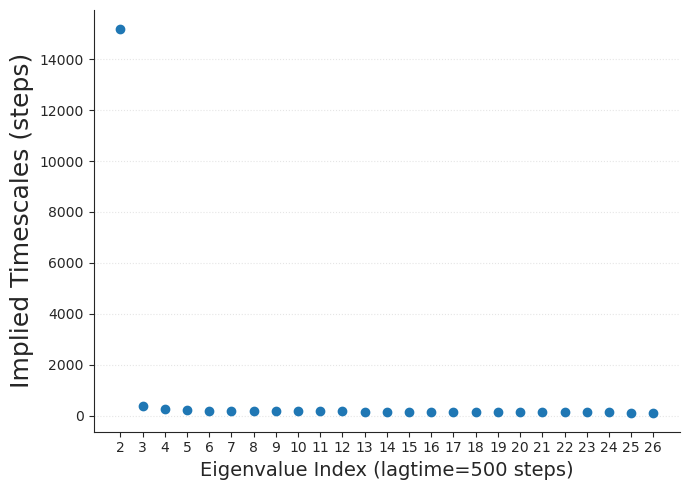

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import deeptime

lagtime = 500

counts = deeptime.markov.TransitionCountEstimator(lagtime=lagtime, count_mode="sliding").fit_fetch(discrete_trajs)
msm = deeptime.markov.msm.MaximumLikelihoodMSM().fit_from_counts(counts).fetch_model()

timescales = msm.timescales()[0:25]

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(timescales, linewidth=0, marker='o', color='#1f77b4', markersize=6) 

ax.set_xlabel(f'Eigenvalue Index (lagtime={lagtime} steps)', fontsize=14)
ax.set_ylabel('Implied Timescales (steps)', fontsize=18)

x_coordinates = np.arange(len(timescales))
ax.set_xticks(x_coordinates)


tick_labels = np.arange(2, 2 + len(timescales))
ax.set_xticklabels(tick_labels, fontsize=10)

# Optional: clean publication layout additions
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Show the plot
plt.tight_layout()
fig.savefig('4_timescale_separation.png', dpi=300)
plt.show()

### Chapman-Kolmogorov test
Adjust `n_sets` to the number of states to coarse grain <br>
`lagt` or `lags` determines the lag time tested

Trained MSM model with lag time 500
Trained MSM model with lag time 1000
Trained MSM model with lag time 1500
Trained MSM model with lag time 2000
Trained MSM model with lag time 2500
Trained MSM model with lag time 3000
Trained MSM model with lag time 3500
Trained MSM model with lag time 4000


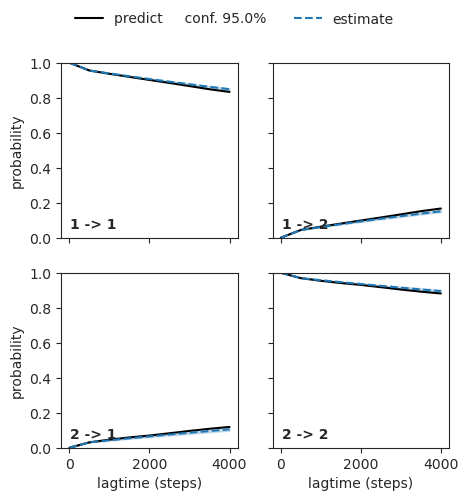

In [79]:
from deeptime.clustering import KMeans
from deeptime.data import ellipsoids
from deeptime.markov import TransitionCountEstimator
from deeptime.markov.msm import MaximumLikelihoodMSM, BayesianMSM
from deeptime.plots.chapman_kolmogorov import plot_ck_test
import os
import numpy as np
import matplotlib.pyplot as plt

n_sets = 2

def load_ktraj_data(data_dir):
    files = sorted([f for f in os.listdir(data_dir) if f.endswith('.npy')])
    data = [np.load(os.path.join(data_dir, f)) for f in files]
    return data

data_dir = 'ktrajs'
micro_trajs = load_ktraj_data(data_dir)
dtraj = [traj.squeeze().astype(int) for traj in micro_trajs]

# Train models with different lag times
models = []
lagt=500
lags = [lagt *(i+1) for i in range(8)]
for lag in lags:
    counts_estimator = TransitionCountEstimator(lagtime=lag, count_mode='effective')
    model = BayesianMSM().fit_fetch(counts_estimator.fit_fetch(dtraj).submodel_largest())
    models.append(model)
    print(f"Trained MSM model with lag time {lag}")

testcounts = TransitionCountEstimator(lagtime=lagt, count_mode='effective')
test_model = BayesianMSM().fit_fetch(testcounts.fit_fetch(dtraj).submodel_largest())
ck_test_results = test_model.ck_test(models, n_metastable_sets=n_sets)

grid = plot_ck_test(ck_test_results, legend=True)
plt.savefig('4_cktest_comparison.png')
plt.show()

# 5. Coarse-grain transition probability matrix
***

In [111]:
import pyemma
import matplotlib.pyplot as plt
import os
import numpy as np
import deeptime.markov.hmm as hmm
from deeptime.util.validation import implied_timescales
from deeptime.plots import plot_implied_timescales

def load_ktraj_data(data_dir):
    files = sorted([f for f in os.listdir(data_dir) if f.endswith('.npy')])
    data = [np.load(os.path.join(data_dir, f)) for f in files]
    return data

data_dir = 'ktrajs'
micro_trajs = load_ktraj_data(data_dir)
discrete_trajs = [traj.flatten() for traj in micro_trajs]


*Estimate PMM*
<br> Adjust `n_hiddenstates` to number of states to coarse grain, and `lagtime` to use in PMM estimation

In [80]:
estimator = deeptime.markov.hmm.init.discrete.metastable_from_data(discrete_trajs, n_hidden_states=2, lagtime=500)

*Estimate HMM* <br>
Adjust `lagtime` to use in the HMM estimator

In [81]:
from msmbuilder.io import load_trajs, save_trajs, save_generic
import deeptime
hidden = deeptime.markov.hmm.MaximumLikelihoodHMM(initial_model=estimator, lagtime=500).fit_fetch(discrete_trajs)
save_generic(hidden, 'hmm.pickl')

*View transition matrix*

In [82]:
from msmbuilder.io import load_trajs, save_generic, preload_top, backup, load_generic
testhmm = load_generic("hmm.pickl")
print(testhmm.transition_model.transition_matrix)

[[0.97976248 0.02023752]
 [0.01499907 0.98500093]]


# 6. Analysis
***

*Microstate mapping to coarse states*

In [83]:
microstate_mapping = testhmm.metastable_assignments
unique_states = np.unique(microstate_mapping)
metastable_states = []

# Group indices by microstate
for state in unique_states:
    indices = np.where(microstate_mapping == state)[0].tolist()
    metastable_states.append(indices)
    
pcca_sets = metastable_states

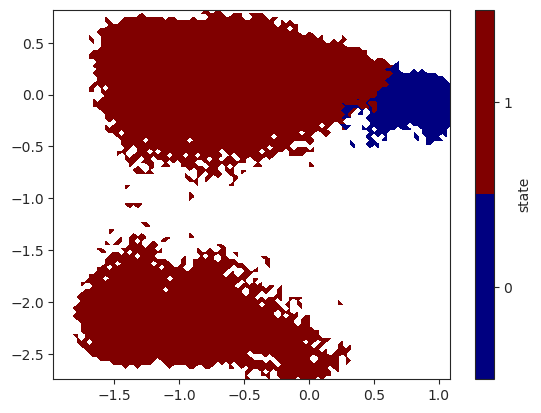

In [84]:
import pyemma
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from msmbuilder.io import load_trajs, load_generic

kclusters = load_generic('kclusters.pickl')
meta, ktrajs = load_trajs('ktrajs')
meta, ttrajs = load_trajs('ttrajs', meta)

dtrajc = np.concatenate(list(ktrajs.values()))
txx = np.concatenate(list(ttrajs.values()))

state_trajectories = np.array([microstate_mapping[dtraj] for dtraj in dtrajc])

xall = np.vstack(txx)[:, 0].flatten()
yall = np.vstack(txx)[:, 1].flatten()

# Plot state map
pyemma.plots.plot_state_map(xall, yall, state_trajectories, cmap = "jet")
plt.savefig('5_statemap.png')
plt.show()


In [85]:
import numpy as np

kclusters = load_generic('kclusters.pickl')

def get_highest_prob_indices(membership_matrix):
    membership_matrix = np.array(membership_matrix)
    highest_prob_indices = np.argmax(membership_matrix, axis=0)
    
    return highest_prob_indices.tolist()

highest_indices = get_highest_prob_indices(testhmm.metastable_memberships)

print(highest_indices)

rpos = []
xpos = kclusters.cluster_centers_[:, 0]
ypos = kclusters.cluster_centers_[:, 1]
for cluster in highest_indices:
    rpos.append([xpos[cluster], ypos[cluster]])

[29, 0]


*Remove floating point errors in transition matrix estimation*

In [86]:
testhmm = load_generic("hmm.pickl")

transition_matrix = testhmm.transition_model.transition_matrix

# Set any probabilities below 10^-10 to 0
threshold = 1e-10
transition_matrix[transition_matrix < threshold] = 0

# Renormalize the matrix along the rows
transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)
print(transition_matrix)

[[0.97976248 0.02023752]
 [0.01499907 0.98500093]]


<Figure size 1000x800 with 0 Axes>

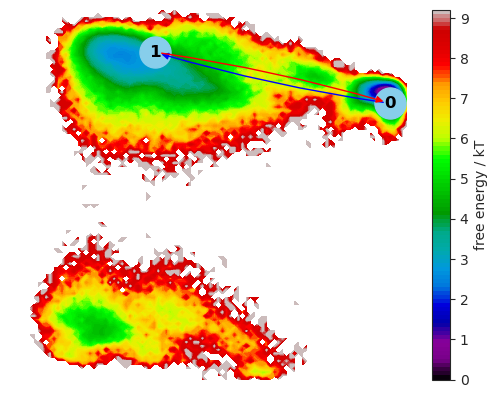

In [87]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from msmbuilder.io import load_trajs, save_generic, preload_top, backup, load_generic
import pyemma.plots as mplt

T = transition_matrix
cluster_centers = rpos

plt.figure(figsize=(10, 8))

meta, ttrajs = load_trajs('ttrajs')
txx = np.concatenate(list(ttrajs.values()))
kclusters = load_generic('kclusters.pickl')

mplt.plot_free_energy(np.vstack(txx)[:,0], np.vstack(txx)[:,1])

G = nx.MultiDiGraph()
pos = {}
for i, center in enumerate(cluster_centers):
    G.add_node(i, pos=center)
    pos[i] = center

nx.draw(G, pos, with_labels=True, node_size=500, node_color='skyblue', font_size=12, font_weight='bold')

#add transition arrows
for i in range(T.shape[0]):
    for j in range(T.shape[1]):
        if i!=j:
            if T[i, j] > 0:
                G.add_edge(i, j, weight=T[i, j])
ax = plt.gca()
checkedge = []

# Draw arrows
for e in G.edges(data=True):
    dist = ((pos[e[0]][0]-pos[e[1]][0])**2 + (pos[e[0]][1]-pos[e[1]][1])**2)**(0.5)
    check = [e[0], e[1]]
    if check in checkedge:
        arrow_color = 'red'
    else:
        arrow_color = 'blue'
    checkedge.append([e[1], e[0]])
    ax.annotate("",
                xy=pos[e[0]], xycoords='data',
                xytext=pos[e[1]], textcoords='data',
                arrowprops=dict(arrowstyle="<|-", color=arrow_color,
                                shrinkA=5, shrinkB=5,
                                patchA=None, patchB=None,
                                connectionstyle="arc3,rad=rrr".replace('rrr', str(0.07/(dist+0.07))),
                                ),
                )
#plt.title("TITLE")
plt.savefig('5_transitiondiagram_hmm.png')

In [88]:
print(testhmm.transition_model.stationary_distribution)

[0.42566739 0.57433261]


### Sample representative structures

In [89]:
import mdtraj as md
import os

from msmbuilder.io.sampling import sample_states
from msmbuilder.io import load_trajs, save_generic, preload_top, backup, load_generic

import matplotlib
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import pyemma.plots as mplt

## Load
meta, ttrajs = load_trajs('ttrajs')
kclusters = load_generic("kclusters.pickl")

microstate_mapping = testhmm.metastable_assignments
unique_states = np.unique(microstate_mapping)
metastable_states = []

avgpos = []
for cluster in highest_indices:
    avgpos.append(kclusters.cluster_centers_[cluster])

## Sample
inds = sample_states(ttrajs,
                     avgpos,
                     k=30)
save_generic(inds, "cg-sample-inds.pickl")

## Make trajectories
top = preload_top(meta)
out_folder = "5_coarsegrained_hmm"
backup(out_folder)
os.mkdir(out_folder)

index_file = os.path.join(out_folder, "index.txt")

with open(index_file, 'w') as f:
    f.write("State\tTrajectory\tFrame\n")  # Header

    for state_i, state_inds in enumerate(inds):
        traj = md.join(
            md.load_frame(meta.loc[traj_i]['traj_fn'], index=frame_i, top=top)
            for traj_i, frame_i in state_inds
        )
        traj.save("{}/{}.xtc".format(out_folder, state_i))

        # Write the indices to the file
        for traj_i, frame_i in state_inds:
            f.write(f"{state_i}\t{traj_i}\t{frame_i}\n")

*MFPT and rates* <br>
Adjust `n_sets` for the number of coarse states, `transition_lt` for $\tau$ the lagtime

In [177]:
from deeptime.markov.tools.analysis import mfpt
import numpy as np
T = transition_matrix

n_sets = 2
transition_lt = 50  ###in ns
mfpt_matrix = np.zeros((n_sets, n_sets))
kmatrix = np.zeros((n_sets, n_sets))
for i in range(n_sets):
    for j in range(n_sets):
        if i != j:
            mfpt_matrix[i, j] = mfpt(T=T, origin=[i], target=[j], tau=transition_lt)
            if mfpt_matrix[i, j] != 0:
                kmatrix[i,j] = 1/mfpt_matrix[i,j]
        else:
            mfpt_matrix[i, j] = 0
print("MFPT:")
print(mfpt_matrix)
print("Rates:")
print(kmatrix)

MFPT:
[[   0.         2470.65813515]
 [3333.54062912    0.        ]]
Rates:
[[0.         0.00040475]
 [0.00029998 0.        ]]


*Plot network map*

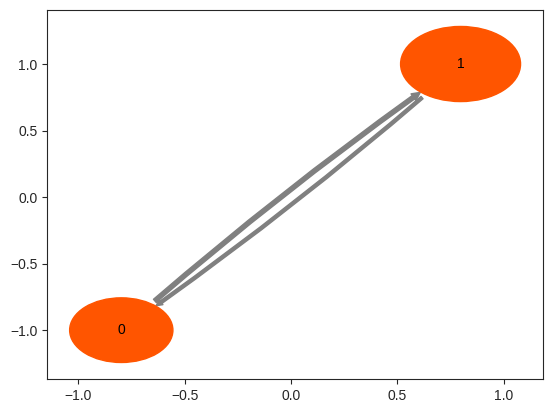

In [165]:
import deeptime

deeptime.plots.plot_markov_model(msm=transition_matrix, edge_labels = None)
plt.savefig("5_transition_model")

In [ ]:
import deeptime
source = [4]
target = [3]
rflux = deeptime.markov.msm.MarkovStateModel(T).reactive_flux(source, target)
deeptime.plots.plot_flux(rflux)
plt.savefig("5_flux.png")

### TICA analysis

In [166]:
import numpy as np
import os

N = np.load('feat/0.npy')
L = np.load('ttrajs/0.npy')

print(f"N shape: {N.shape}")
print(f"L shape: {L.shape}")

M = np.linalg.pinv(N) @ L

print(f"Computed M shape: {M.shape}")

output_path = '6_TICAweights.npy'
np.save(output_path, M)
print(f"M saved to {output_path}")

N shape: (100001, 36)
L shape: (100001, 12)
Computed M shape: (36, 12)
M saved to 6_TICAweights.npy


In [170]:
viewM = np.load('6_TICAweights.npy')
print(viewM.T[0])

[-0.02813148 -0.01092364 -0.02011936 -0.01297051 -0.06749697 -0.10229828
 -0.02163482  0.0221949  -0.18827757  0.39869448  0.36614053 -0.14769482
  0.06682747 -0.14738837  0.22182722 -0.25859295 -0.03503407 -0.08397643
  0.00813693 -0.20482516  0.09834545  0.07707539  0.17978944 -0.18299262
 -0.05490296 -0.0180791   0.18041376  0.14175656  0.0253691  -0.08355491
 -0.03023239 -0.00341703 -0.04570306 -0.01249407 -0.00912945  0.0355118 ]


*For visualising with PyMOL (works only for torsional angle features)*

In [2]:
import numpy as np

sampleTIC = 1 #0 index based

data = np.load('6_TICAweights.npy')
trans = data.T

residue_ends = [0,10]
chain_starts = [0] + residue_ends[:-1]  # [0, 21]

cnt = 0
contr = []
for i in range(residue_ends[-1]):
    if i in chain_starts:
        contr.append(np.sum(np.abs(trans[sampleTIC][cnt:cnt+2])))
        cnt += 2
    else:
        contr.append(np.sum(np.abs(trans[sampleTIC][cnt:cnt+4])))
        cnt += 4
print(contr)
#print(np.sum(np.abs(trans[0][0:2])))

with open(f'6_residuecontrTIC{sampleTIC+1}.txt', 'w') as f:
    for value in contr:
        f.write(f"{value}\n")

[0.01514064425307654, 0.04223552545599591, 0.9231278013099371, 1.6270029484928437, 0.2941976582454914, 0.3413361661002979, 0.20290912402235045, 0.15413356900570277, 0.05159997605796015, 0.041962332519719286]
